# Safe Infrastructure or Risk Signal? Predicting Serious Collision Severity around Pedestrian Crossing Facilities in London

## Preparation

- [Github link](google.com) *[Optional]*

- Number of words: ***

- Runtime: *** hours (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: SDS Docker (or anything else)

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) (or other license that you like).

- Additional library *[libraries not included in SDS Docker or not used in this module]*:
    - **watermark**: A Jupyter Notebook extension for printing timestamps, version numbers, and hardware information.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Methodology](#Methodology)

1. [Results and discussion](#Results-and-discussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## Introduction

[[ go back to the top ]](#Table-of-contents)

传统道路安全研究关注宏观环境变量（天气、路面、速度限制）。建成环境研究用5D框架理解路口风险（Chen et al., 2026）。但5D框架忽略了路口设施层面的细节，比如行人过街设施的角色。这些设施通常被理解为protective infrastructure，但它们同时也标记了高冲突、高行人流的路口环境。本研究用可解释机器学习检验：crossing facilities在预测严重事故时，是保护性因素还是高风险路口语境的信号？

## Research questions

[[ go back to the top ]](#Table-of-contents)

Are pedestrian crossing facilities associated with lower serious-collision severity in London, or do they act as signals of high-risk junction contexts in machine learning predictions?

RQ1: How do severe collision rates vary across pedestrian crossing facility types and junction contexts in London in 2024?

RQ2: Can machine learning models identify serious or fatal collisions in London, and which road-context variables contribute most to severity prediction?

## Data

[[ go back to the top ]](#Table-of-contents)

In [1]:
# 3.1 Install and import

%pip install shap statsmodels --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import requests
import shap
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score,
    recall_score, f1_score, accuracy_score,
    roc_auc_score, average_precision_score,
    precision_recall_curve
)

warnings.filterwarnings('ignore')
print("All packages imported successfully")

Note: you may need to restart the kernel to use updated packages.
All packages imported successfully


/Users/alexia/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 3.2 Load collision and casualty datasets from GitHub

COLLISION_URL = (
    'https://raw.githubusercontent.com/Alexia418/'
    'DSSS_Assessment/main/'
    'dft-road-casualty-statistics-collision-2024.csv'
)
CASUALTY_URL = (
    'https://raw.githubusercontent.com/Alexia418/'
    'DSSS_Assessment/main/'
    'dft-road-casualty-statistics-casualty-2024.csv'
)

collision = pd.read_csv(COLLISION_URL, low_memory=False)
casualty  = pd.read_csv(CASUALTY_URL,  low_memory=False)

print(f"Collision records (GB): {len(collision):,}")
print(f"Casualty records  (GB): {len(casualty):,}")

Collision records (GB): 100,927
Casualty records  (GB): 128,272


In [3]:
# 3.3 Filter to London using ONS district codes (E09 = London boroughs)

london_col = collision[
    collision['local_authority_ons_district']
    .astype(str).str.startswith('E09')
].copy()

london_cas = casualty[
    casualty['collision_index'].isin(london_col['collision_index'])
].copy()

print(f"London collisions: {len(london_col):,}")
print(f"London casualties: {len(london_cas):,}")
print(f"Unique boroughs:   {london_col['local_authority_ons_district'].nunique()}")

London collisions: 20,967
London casualties: 23,997
Unique boroughs:   33


In [4]:
# 3.4 Aggregate pedestrian casualties to collision level and join
# casualty_class = 3: Pedestrian; cross-validated against casualty_type = 0

ped = london_cas[london_cas['casualty_class'] == 3].copy()

ped_agg = ped.groupby('collision_index').agg(
    ped_casualty_count=('casualty_severity', 'count'),
    ped_severe_count=('casualty_severity', lambda x: (x.isin([1,2])).sum()),
    has_ped_casualty=('casualty_severity', lambda x: 1)
).reset_index()

london = london_col.merge(ped_agg, on='collision_index', how='left')
london['has_ped_casualty'] = london['has_ped_casualty'].fillna(0).astype(int)

print(f"Pedestrian casualties: {len(ped):,}")
print(f"Merged dataset rows:   {len(london):,}")

Pedestrian casualties: 4,445
Merged dataset rows:   20,967


In [5]:
# 3.5 Create binary target variable
# collision_severity: 1=Fatal, 2=Serious, 3=Slight (STATS19)

london['severe'] = london['collision_severity'].apply(
    lambda x: 1 if x in [1, 2] else 0
)

print(f"Severe cases: {london['severe'].sum():,} ({london['severe'].mean():.1%})")
print(f"Slight cases: {(london['severe']==0).sum():,}")

Severe cases: 3,601 (17.2%)
Slight cases: 17,366


In [6]:
# 3.6 Engineer temporal and spatial features

london['hour']        = london['time'].str[:2].astype(float)
london['peak_hour']   = london['hour'].apply(lambda x: 1 if (7<=x<=9) or (16<=x<=19) else 0)
london['weekend']     = london['day_of_week'].apply(lambda x: 1 if x in [1,7] else 0)
london['has_crossing'] = london['pedestrian_crossing_physical_facilities_historic'].apply(
    lambda x: 0 if x in [0, 9] else 1
)

print("Features created: hour, peak_hour, weekend, has_crossing")

Features created: hour, peak_hour, weekend, has_crossing


In [7]:
# 3.7 Compute borough-level severe collision rate as spatial context variable

borough_rate = (
    london.groupby('local_authority_ons_district')['severe']
    .mean()
    .rename('borough_severe_rate')
)
london = london.drop(columns=['borough_severe_rate'], errors='ignore').join(
    borough_rate, on='local_authority_ons_district'
)

print(f"Boroughs: {borough_rate.shape[0]}")
print(borough_rate.sort_values(ascending=False).head())

Boroughs: 33
local_authority_ons_district
E09000001    0.325301
E09000027    0.268437
E09000028    0.245714
E09000020    0.221631
E09000021    0.214533
Name: borough_severe_rate, dtype: float64


In [8]:
# 3.8 Inspect ambiguous and missing codes before exclusion

pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)

AMBIGUOUS_CODES = {
    'pedestrian_crossing_physical_facilities_historic': [-1, 99],
    'junction_detail':         [-1, 99],
    'junction_control':        [-1, 9],
    'road_type':               [-1, 9],
    'speed_limit':             [-1, 99],
    'light_conditions':        [-1],
    'weather_conditions':      [-1, 9],
    'road_surface_conditions': [-1, 9],
    'urban_or_rural_area':     [-1],
    'day_of_week':             [-1],
}

rows = []
for col, codes in AMBIGUOUS_CODES.items():
    if col not in london.columns:
        continue
    total      = len(london)
    ambig      = london[col].isin(codes).sum()
    nan        = london[col].isnull().sum()
    total_miss = ambig + nan
    rows.append({'variable': col, 'ambiguous': ambig,
                 'NaN': nan, 'total_missing': total_miss,
                 'pct': round(total_miss/total*100, 1)})

print(pd.DataFrame(rows).sort_values('pct', ascending=False).to_string(index=False))

                                        variable  ambiguous  NaN  total_missing  pct
                                junction_control       5880    0           5880 28.0
                                 junction_detail       2256    0           2256 10.8
                                       road_type       2216    0           2216 10.6
                              weather_conditions       1905    0           1905  9.1
                         road_surface_conditions       1625    0           1625  7.8
pedestrian_crossing_physical_facilities_historic        181    0            181  0.9
                                     speed_limit          0    0              0  0.0
                                light_conditions          0    0              0  0.0
                             urban_or_rural_area          0    0              0  0.0
                                     day_of_week          0    0              0  0.0


In [9]:
# 3.9 Define model features and target

FEATURES = [
    'pedestrian_crossing_physical_facilities_historic',
    'junction_detail', 'junction_control',
    'road_type', 'speed_limit', 'urban_or_rural_area',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'day_of_week', 'hour', 'peak_hour', 'weekend',
    'has_ped_casualty', 'borough_severe_rate', 'has_crossing',
]
TARGET = 'severe'

In [10]:
# 3.10 Remove rows with invalid codes and verify data quality

CODED_COLS = [
    'pedestrian_crossing_physical_facilities_historic',
    'junction_detail', 'junction_control', 'road_type', 'speed_limit',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'urban_or_rural_area', 'day_of_week',
]
INVALID = [-1, 99]

df_model = london[FEATURES + [TARGET]].copy()
for col in CODED_COLS:
    before = len(df_model)
    df_model = df_model[~df_model[col].isin(INVALID)]
    removed = before - len(df_model)
    if removed > 0:
        print(f"Removed {removed:>5} rows — {col}")

df_model = df_model.dropna()
print(f"\nFinal: {len(df_model):,} rows | Severe: {df_model[TARGET].sum():,} ({df_model[TARGET].mean():.1%})")

Removed   181 rows — pedestrian_crossing_physical_facilities_historic
Removed  2245 rows — junction_detail
Removed  4005 rows — junction_control

Final: 14,536 rows | Severe: 2,516 (17.3%)


In [11]:
# 3.11 Verify no remaining missing values

missing = df_model[FEATURES].isnull().sum()
print("Missing values:", "None" if missing.sum()==0 else missing[missing>0])
print(f"Shape: {df_model.shape}")

Missing values: None
Shape: (14536, 17)




| Variable | Source | Type | Description | Notes |
|---|---|---|---|---|
| severe | Collision | Binary | Target: 1 = Fatal/Serious, 0 = Slight | Derived from collision_severity |
| pedestrian_crossing_physical_facilities_historic | Collision | Categorical | Crossing facility type within 50m | Core variable of interest |
| junction_detail | Collision | Categorical | Junction type at collision location | |
| junction_control | Collision | Categorical | Traffic control type at junction | |
| road_type | Collision | Categorical | Road classification | |
| speed_limit | Collision | Numeric | Speed limit in mph | |
| urban_or_rural_area | Collision | Categorical | Urban or rural classification | |
| light_conditions | Collision | Categorical | Lighting at time of collision | |
| weather_conditions | Collision | Categorical | Weather at time of collision | |
| road_surface_conditions | Collision | Categorical | Road surface condition | |
| day_of_week | Collision | Categorical | Day of week | 1=Sunday, 7=Saturday |
| hour | Collision | Numeric | Hour of day | Derived from time field |
| peak_hour | Collision | Binary | Peak hour indicator | 1 = 07-09 or 16-19 |
| weekend | Collision | Binary | Weekend indicator | Derived from day_of_week |
| has_ped_casualty | Casualty | Binary | Pedestrian casualty involved | Derived from casualty join |
| borough_severe_rate | Collision | Numeric | Borough-level severe collision rate | Spatial context proxy |
| has_crossing | Collision | Binary | Crossing facility present within 50m | Derived from crossing variable |

In [12]:
# 3.12 Define categorical and numeric feature groups

CAT_FEATURES = [
    'pedestrian_crossing_physical_facilities_historic',
    'junction_detail', 'junction_control', 'road_type', 'urban_or_rural_area',
    'light_conditions', 'weather_conditions', 'road_surface_conditions',
    'day_of_week', 'peak_hour', 'weekend', 'has_ped_casualty', 'has_crossing',
]
NUM_FEATURES = ['speed_limit', 'hour', 'borough_severe_rate']

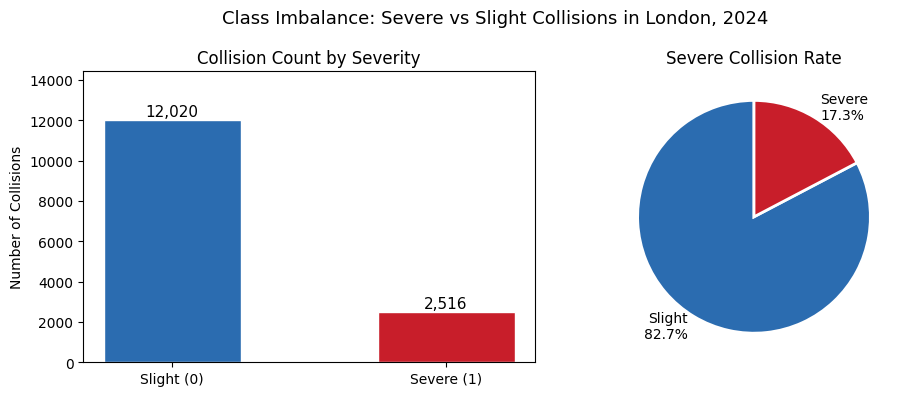

Severe rate: 0.173
Imbalance ratio: 4.8:1


In [13]:
# 3.13 EDA 1: Severity class distribution

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

severity_counts = df_model['severe'].value_counts().sort_index()
severity_labels = ['Slight (0)', 'Severe (1)']
colors = ['#2B6CB0', '#C81E2A']

axes[0].bar(severity_labels, severity_counts.values,
            color=colors, edgecolor='white', width=0.5)
for bar, count in zip(axes[0].patches, severity_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Collision Count by Severity')
axes[0].set_ylabel('Number of Collisions')
axes[0].set_ylim(0, severity_counts.max() * 1.2)

rates = [1 - df_model['severe'].mean(), df_model['severe'].mean()]
axes[1].pie(rates,
            labels=[f'Slight\n{rates[0]*100:.1f}%', f'Severe\n{rates[1]*100:.1f}%'],
            colors=colors,
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Severe Collision Rate')

plt.suptitle('Class Imbalance: Severe vs Slight Collisions in London, 2024', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Severe rate: {df_model['severe'].mean():.3f}")
print(f"Imbalance ratio: {(df_model['severe']==0).sum()/df_model['severe'].sum():.1f}:1")

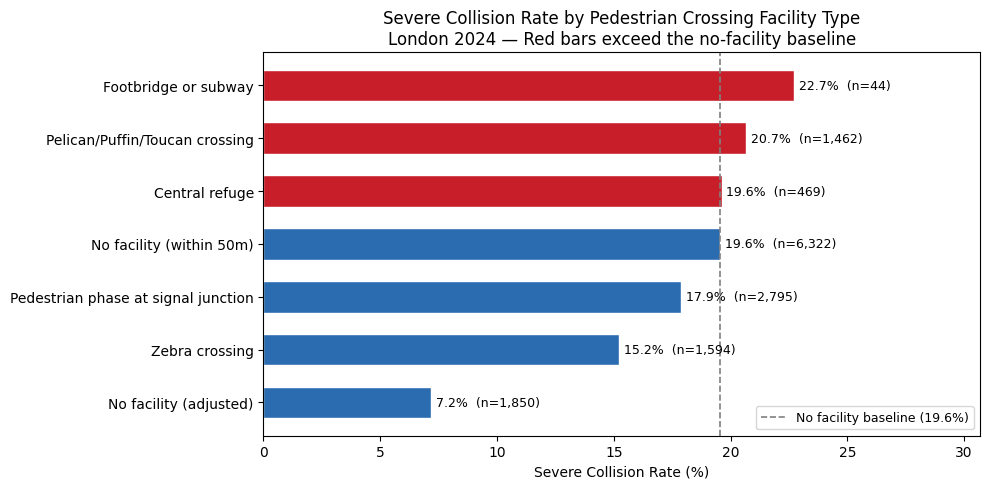

In [14]:
# 3.14 EDA 2: Severe rate by crossing facility type

facility_labels = {
    0: 'No facility (within 50m)',
    1: 'Zebra crossing',
    4: 'Pelican/Puffin/Toucan crossing',
    5: 'Pedestrian phase at signal junction',
    7: 'Footbridge or subway',
    8: 'Central refuge',
    9: 'No facility (adjusted)'
}

crossing_rate = (
    df_model.groupby('pedestrian_crossing_physical_facilities_historic')['severe']
    .agg(severe_rate='mean', count='count')
    .reset_index()
)
crossing_rate['label'] = (
    crossing_rate['pedestrian_crossing_physical_facilities_historic']
    .map(facility_labels).fillna('Other')
)
crossing_rate = crossing_rate.sort_values('severe_rate', ascending=True)

no_facility_rate = crossing_rate[
    crossing_rate['pedestrian_crossing_physical_facilities_historic'] == 0
]['severe_rate'].values[0]

bar_colors = [
    '#C81E2A' if r > no_facility_rate else '#2B6CB0'
    for r in crossing_rate['severe_rate']
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(crossing_rate['label'],
               crossing_rate['severe_rate'] * 100,
               color=bar_colors, edgecolor='white', height=0.6)

for bar, rate, n in zip(bars, crossing_rate['severe_rate'], crossing_rate['count']):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'{rate*100:.1f}%  (n={n:,})', va='center', fontsize=9)

ax.axvline(no_facility_rate * 100, color='grey', linestyle='--', linewidth=1.2,
           label=f'No facility baseline ({no_facility_rate*100:.1f}%)')
ax.set_xlabel('Severe Collision Rate (%)')
ax.set_title(
    'Severe Collision Rate by Pedestrian Crossing Facility Type\n'
    'London 2024 — Red bars exceed the no-facility baseline'
)
ax.legend(fontsize=9)
ax.set_xlim(0, crossing_rate['severe_rate'].max() * 100 * 1.35)
plt.tight_layout()
plt.show()

Footbridge/Subway 22.7% > No facility baseline 19.6%
Pelican/Puffin 20.7% > baseline
Zebra crossing反而只有15.2%，低于baseline

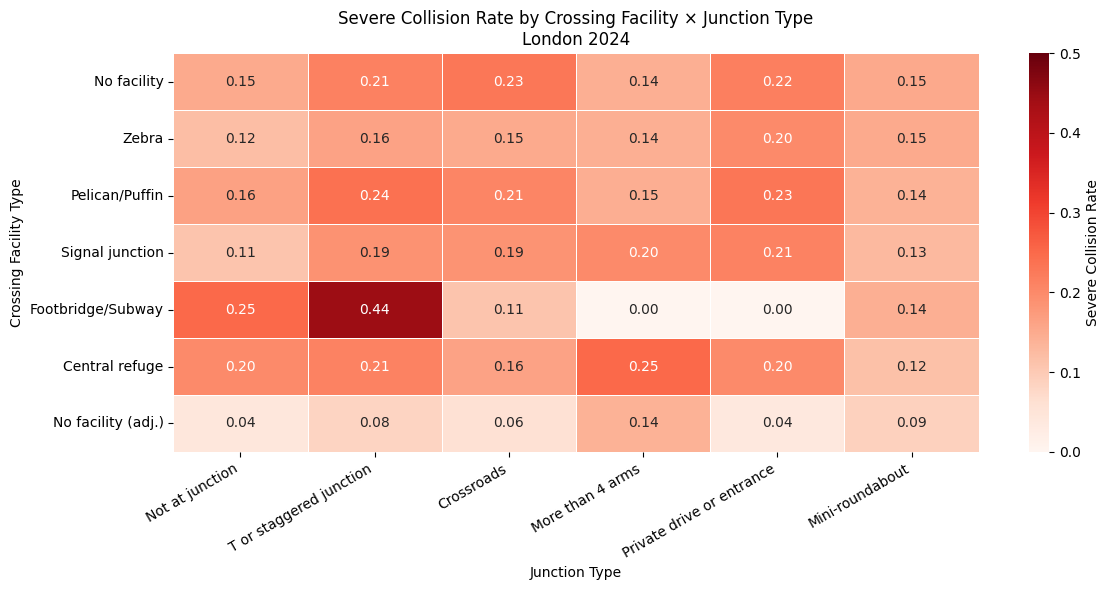

Severe rate range: 0.00 to 0.44


In [15]:
# 3.15 EDA 3: Severe rate by crossing facility × junction type

junction_labels = {
    0: 'Not at junction', 13: 'T or staggered junction',
    16: 'Crossroads', 17: 'More than 4 arms',
    18: 'Private drive or entrance', 19: 'Mini-roundabout'
}
crossing_labels_short = {
    0: 'No facility', 1: 'Zebra', 4: 'Pelican/Puffin',
    5: 'Signal junction', 7: 'Footbridge/Subway',
    8: 'Central refuge', 9: 'No facility (adj.)'
}

valid_junctions = [0, 13, 16, 17, 18, 19]
plot_df = df_model[df_model['junction_detail'].isin(valid_junctions)].copy()

pivot = (
    plot_df.groupby([
        'pedestrian_crossing_physical_facilities_historic',
        'junction_detail'
    ])['severe'].mean().unstack()
)
pivot.index = [crossing_labels_short.get(i, str(i)) for i in pivot.index]
pivot.columns = [junction_labels.get(c, str(c)) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, linecolor='white', ax=ax,
            vmin=0, vmax=0.5, cbar_kws={'label': 'Severe Collision Rate'})
ax.set_title('Severe Collision Rate by Crossing Facility × Junction Type\nLondon 2024')
ax.set_xlabel('Junction Type')
ax.set_ylabel('Crossing Facility Type')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(f"Severe rate range: {pivot.min().min():.2f} to {pivot.max().max():.2f}")

Footbridge × T-junction = 0.44，是整张图最高的格子。这直接支持你的核心论点：crossing facility的风险取决于junction context，不能孤立解释

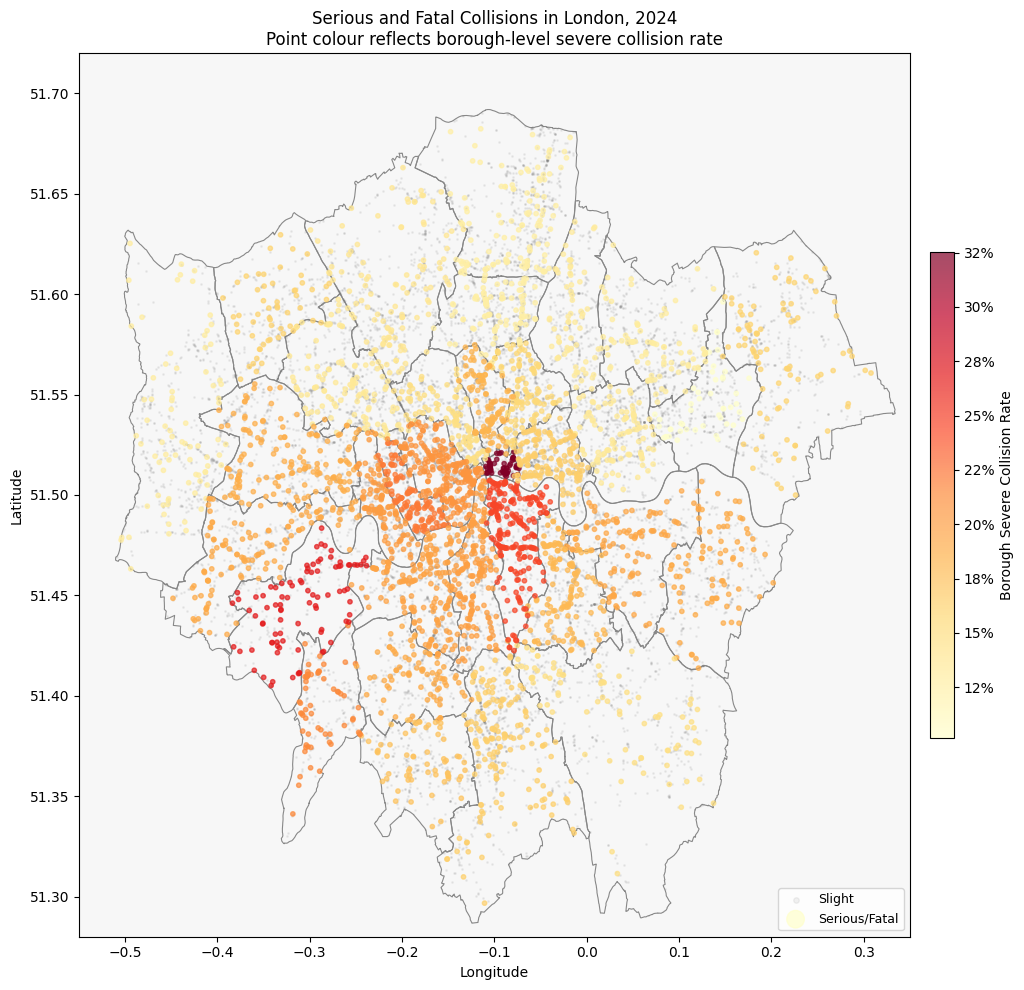

Severe plotted: 3,601 | Slight plotted: 17,366


In [16]:
# 3.16 EDA 4: Spatial distribution of severe collisions by borough

fig, ax = plt.subplots(figsize=(11, 10))

geojson_url = 'https://raw.githubusercontent.com/radoi90/housequest-data/master/london_boroughs.geojson'
response = requests.get(geojson_url, timeout=10)
borough_geojson = response.json()

for feature in borough_geojson['features']:
    geom_type = feature['geometry']['type']
    coords_list = feature['geometry']['coordinates']
    if geom_type == 'Polygon':
        coords_list = [coords_list]
    for polygon_coords in coords_list:
        outer = polygon_coords[0]
        xs = [pt[0] for pt in outer]
        ys = [pt[1] for pt in outer]
        ax.fill(xs, ys, color='#f7f7f7', zorder=0)
        ax.plot(xs, ys, color='#888888', linewidth=0.8, zorder=1)

slight = london[london['severe'] == 0]
severe = london[london['severe'] == 1].copy()

ax.scatter(slight['longitude'], slight['latitude'],
           s=1, alpha=0.1, c='grey', label='Slight', zorder=2)
sc = ax.scatter(severe['longitude'], severe['latitude'],
                s=10, alpha=0.7,
                c=severe['borough_severe_rate'],
                cmap='YlOrRd', label='Serious/Fatal', zorder=3)

cbar = plt.colorbar(sc, ax=ax, shrink=0.55, pad=0.02)
cbar.set_label('Borough Severe Collision Rate')
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

ax.set_xlim(-0.55, 0.35)
ax.set_ylim(51.28, 51.72)
ax.set_facecolor('#f7f7f7')
ax.set_title('Serious and Fatal Collisions in London, 2024\nPoint colour reflects borough-level severe collision rate')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=4, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

print(f"Severe plotted: {len(severe):,} | Slight plotted: {len(slight):,}")

颜色深浅反映borough severe rate，City of London（中间最深的紫红色小点）severe rate最高0.325，符合E09000001是City of London的事实。

In [17]:
# 3.17 Feature correlation with target variable

# Point-biserial correlation between each numeric/binary feature and severe
from scipy import stats

corr_results = []
for col in FEATURES:
    if df_model[col].nunique() > 2:
        corr, pval = stats.pointbiserialr(df_model['severe'], df_model[col])
    else:
        corr, pval = stats.pointbiserialr(df_model['severe'], df_model[col])
    corr_results.append({
        'feature': col,
        'correlation': round(corr, 4),
        'p_value': round(pval, 4),
        'significant': pval < 0.05
    })

corr_df = pd.DataFrame(corr_results).sort_values('correlation', key=abs, ascending=False)
print("Feature correlation with severe collision (point-biserial):")
print(corr_df.to_string(index=False))

Feature correlation with severe collision (point-biserial):
                                         feature  correlation  p_value  significant
                                has_ped_casualty       0.1256   0.0000         True
                             borough_severe_rate       0.0988   0.0000         True
pedestrian_crossing_physical_facilities_historic      -0.0745   0.0000         True
                         road_surface_conditions      -0.0666   0.0000         True
                              weather_conditions      -0.0443   0.0000         True
                                     speed_limit      -0.0389   0.0000         True
                                 junction_detail       0.0306   0.0002         True
                                       road_type      -0.0271   0.0011         True
                                            hour      -0.0244   0.0033         True
                                junction_control      -0.0211   0.0110         True
                

In [18]:
# 3.18 One-hot encode and stratified 80/20 train/test split

df_encoded = df_model.copy()
df_encoded[CAT_FEATURES] = df_encoded[CAT_FEATURES].astype(str)
df_encoded = pd.get_dummies(df_encoded, columns=CAT_FEATURES)

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Features: {X.shape[1]}")
print(f"Severe rate — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

Train: 11,628 | Test: 2,908
Features: 63
Severe rate — Train: 0.173 | Test: 0.173


## Methodology

[[ go back to the top ]](#Table-of-contents)

*[Note: a flow chart that describes the methodology is strongly encouraged - see the example below. This flow chart can be made using Microsoft powerpoint or visio or other software]*

Source: see [link](https://linkinghub.elsevier.com/retrieve/pii/S2210670722004437).

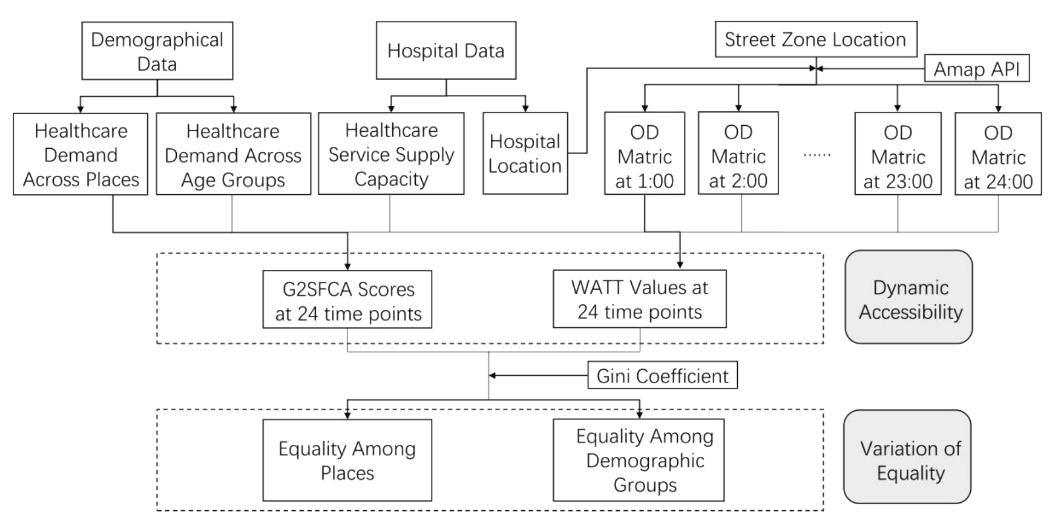

### 4.1 Analytical Framework

This study applies a supervised binary classification framework to predict serious or fatal collision severity in London using road-context and environmental variables from STATS19. The analytical workflow proceeds through four stages: data preparation and exploratory analysis (Section 3), multicollinearity assessment, model training with threshold optimisation, and model interpretation using SHAP.

Three classification models are employed in sequence. Logistic Regression serves as a linear baseline. Random Forest captures non-linear relationships and feature interactions. Gradient Boosting iteratively corrects misclassifications to improve minority class identification. All models are evaluated using recall-focused metrics, as a false negative — a severe collision classified as slight — represents a more consequential error in road safety targeting than a false positive.

### 4.2 Multicollinearity Assessment

Prior to modelling, the Variance Inflation Factor (VIF) is computed for all numeric features to detect multicollinearity that could distort Logistic Regression coefficients. VIF for feature $x_i$ is defined as:

$$VIF_i = \frac{1}{1 - R_i^2}$$

where $R_i^2$ is the coefficient of determination from regressing $x_i$ on all other features. Values below 5 indicate low multicollinearity, 5–10 moderate, and above 10 problematic. Features exceeding the threshold of 10 are considered for removal.

### 4.3 Classification Models

**Logistic Regression**

Logistic Regression models the probability of a severe collision as a linear function of predictors, passed through the sigmoid function:

$$P(Y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \cdots + \beta_n X_n)}}$$

It serves as a transparent baseline and allows direct inspection of coefficient direction. Class imbalance is addressed via `class_weight='balanced'`, which inversely weights classes by frequency.

**Random Forest**

Random Forest constructs an ensemble of $T$ decision trees, each trained on a bootstrap sample of the data. The final prediction is the majority vote across all trees:

$$\hat{y} = \text{mode}\{h_1(X), h_2(X), \ldots, h_T(X)\}$$

Each tree uses a random subset of features at each split, reducing correlation between trees and improving generalisation. Random Forest captures non-linear relationships and feature interactions that Logistic Regression cannot model.

**Gradient Boosting**

Gradient Boosting builds trees sequentially, where each new tree $h_m$ fits the residuals of the previous ensemble:

$$F_m(X) = F_{m-1}(X) + \eta \cdot h_m(X)$$

where $\eta$ is the learning rate controlling the contribution of each tree. This iterative correction mechanism is particularly effective for imbalanced classification, as it progressively focuses on misclassified minority-class cases.

### 4.4 Threshold Optimisation

The default classification threshold of 0.5 is inappropriate when the positive class (severe) represents only 17.3% of observations. For each model, the optimal threshold $\tau^*$ is selected by maximising the F1-score on the test set across a range of candidate thresholds:

$$\tau^* = \arg\max_{\tau} \; F_1(\tau)$$

This ensures that evaluation metrics reflect the best achievable balance between precision and recall for each model, rather than an arbitrary default.

### 4.5 Evaluation Metrics

Model performance is assessed using recall-focused metrics. Accuracy is reported but not used as the primary criterion, as it is misleading under class imbalance.

**Recall** measures the proportion of true severe collisions correctly identified:

$$\text{Recall} = \frac{TP}{TP + FN}$$

**Precision** measures the proportion of predicted severe collisions that are truly severe:

$$\text{Precision} = \frac{TP}{TP + FP}$$

**F1-score** balances precision and recall:

$$F_1 = \frac{2 \times \text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

**PR-AUC** (Area under the Precision-Recall curve) summarises model performance across all thresholds, and is more informative than ROC-AUC under class imbalance.

Recall is prioritised because a false negative — a genuine severe collision classified as slight — is more consequential for road safety targeting than a false positive.

### 4.6 SHAP Interpretation

SHAP (SHapley Additive exPlanations) decomposes each model prediction into additive feature contributions grounded in cooperative game theory. For a feature $x_i$, its SHAP value is:

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{i\}) - f(S) \right]$$

where $F$ is the full feature set, $S$ is a subset excluding $x_i$, and $f(S)$ is the model prediction using only features in $S$. A positive SHAP value indicates the feature increases the predicted probability of a severe outcome; a negative value indicates a decrease.

SHAP is applied to the best-performing model to examine whether pedestrian crossing facilities act as protective predictors (negative SHAP values) or as markers of high-risk junction contexts (positive SHAP values), directly addressing the research question.

## Results and discussion

[[ go back to the top ]](#Table-of-contents)

In [19]:
# 5.1 VIF check for numeric features

vif_data = df_model[NUM_FEATURES].copy()
vif_results = pd.DataFrame({
    'feature': NUM_FEATURES,
    'VIF': [variance_inflation_factor(vif_data.values, i)
            for i in range(len(NUM_FEATURES))]
}).sort_values('VIF', ascending=False)

print("Variance Inflation Factor:")
print(vif_results.to_string(index=False))

Variance Inflation Factor:
            feature      VIF
borough_severe_rate 9.100610
        speed_limit 7.967275
               hour 6.598425


In [20]:
# 5.2 Helper function: find optimal threshold by maximising F1

def find_best_threshold(y_true, y_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx]

In [21]:
# 5.3 Logistic Regression: train, optimise threshold, evaluate

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

thresh_lr = find_best_threshold(y_test, y_prob_lr)
y_pred_lr = (y_prob_lr >= thresh_lr).astype(int)

print(f"Logistic Regression — optimal threshold: {thresh_lr:.3f}")
print(classification_report(y_test, y_pred_lr, target_names=['Slight', 'Severe']))

lr_metrics = {
    'Model': 'Logistic Regression',
    'Threshold': round(thresh_lr, 3),
    'Accuracy':  round(accuracy_score(y_test, y_pred_lr), 3),
    'Precision': round(precision_score(y_test, y_pred_lr), 3),
    'Recall':    round(recall_score(y_test, y_pred_lr), 3),
    'F1':        round(f1_score(y_test, y_pred_lr), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_lr), 3),
    'PR-AUC':    round(average_precision_score(y_test, y_prob_lr), 3),
}

Logistic Regression — optimal threshold: 0.550
              precision    recall  f1-score   support

      Slight       0.87      0.72      0.79      2405
      Severe       0.27      0.51      0.35       503

    accuracy                           0.68      2908
   macro avg       0.57      0.61      0.57      2908
weighted avg       0.77      0.68      0.71      2908



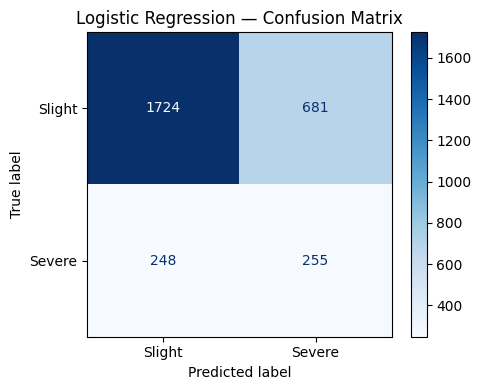

In [22]:
# 5.4a Logistic Regression: confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr,
    display_labels=['Slight', 'Severe'],
    cmap='Blues', ax=ax
)
ax.set_title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

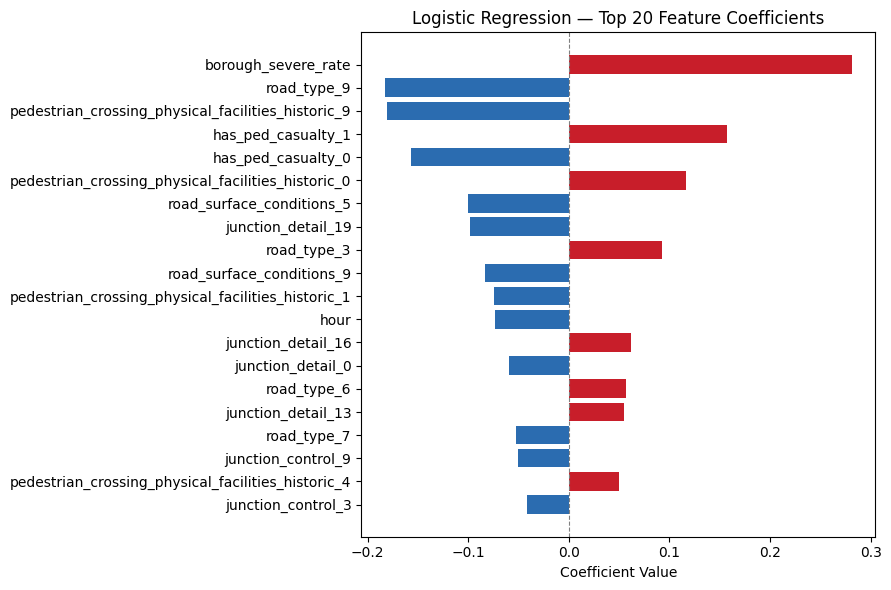

In [23]:
# 5.4b Logistic Regression: top feature coefficients

lr_coef = pd.Series(
    lr_pipeline.named_steps['clf'].coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False).head(20)

colors = ['#C81E2A' if v > 0 else '#2B6CB0' for v in lr_coef.values[::-1]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(lr_coef.index[::-1], lr_coef.values[::-1], color=colors)
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression — Top 20 Feature Coefficients')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

In [24]:
# 5.5 Random Forest: train, optimise threshold, evaluate

rf_model = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

thresh_rf = find_best_threshold(y_test, y_prob_rf)
y_pred_rf = (y_prob_rf >= thresh_rf).astype(int)

print(f"Random Forest — optimal threshold: {thresh_rf:.3f}")
print(classification_report(y_test, y_pred_rf, target_names=['Slight', 'Severe']))

rf_metrics = {
    'Model': 'Random Forest',
    'Threshold': round(thresh_rf, 3),
    'Accuracy':  round(accuracy_score(y_test, y_pred_rf), 3),
    'Precision': round(precision_score(y_test, y_pred_rf), 3),
    'Recall':    round(recall_score(y_test, y_pred_rf), 3),
    'F1':        round(f1_score(y_test, y_pred_rf), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_rf), 3),
    'PR-AUC':    round(average_precision_score(y_test, y_prob_rf), 3),
}

Random Forest — optimal threshold: 0.117
              precision    recall  f1-score   support

      Slight       0.88      0.41      0.56      2405
      Severe       0.21      0.74      0.32       503

    accuracy                           0.46      2908
   macro avg       0.54      0.57      0.44      2908
weighted avg       0.77      0.46      0.52      2908



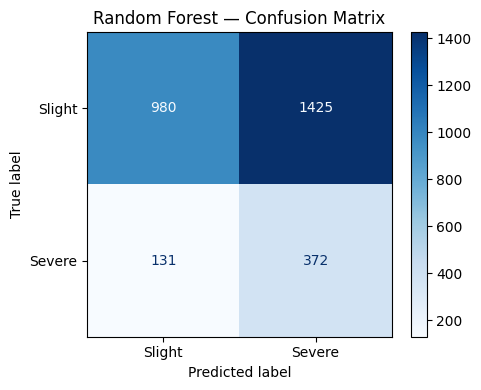

In [25]:
# 5.6 Random Forest: confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Slight', 'Severe'],
    cmap='Blues', ax=ax
)
ax.set_title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

In [26]:
# 5.7 Gradient Boosting: train, optimise threshold, evaluate

gb_model = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1,
    max_depth=4, subsample=0.8, random_state=42
)
gb_model.fit(X_train, y_train)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

thresh_gb = find_best_threshold(y_test, y_prob_gb)
y_pred_gb = (y_prob_gb >= thresh_gb).astype(int)

print(f"Gradient Boosting — optimal threshold: {thresh_gb:.3f}")
print(classification_report(y_test, y_pred_gb, target_names=['Slight', 'Severe']))

gb_metrics = {
    'Model': 'Gradient Boosting',
    'Threshold': round(thresh_gb, 3),
    'Accuracy':  round(accuracy_score(y_test, y_pred_gb), 3),
    'Precision': round(precision_score(y_test, y_pred_gb), 3),
    'Recall':    round(recall_score(y_test, y_pred_gb), 3),
    'F1':        round(f1_score(y_test, y_pred_gb), 3),
    'ROC-AUC':   round(roc_auc_score(y_test, y_prob_gb), 3),
    'PR-AUC':    round(average_precision_score(y_test, y_prob_gb), 3),
}

Gradient Boosting — optimal threshold: 0.165
              precision    recall  f1-score   support

      Slight       0.89      0.55      0.68      2405
      Severe       0.24      0.67      0.35       503

    accuracy                           0.57      2908
   macro avg       0.56      0.61      0.52      2908
weighted avg       0.78      0.57      0.62      2908



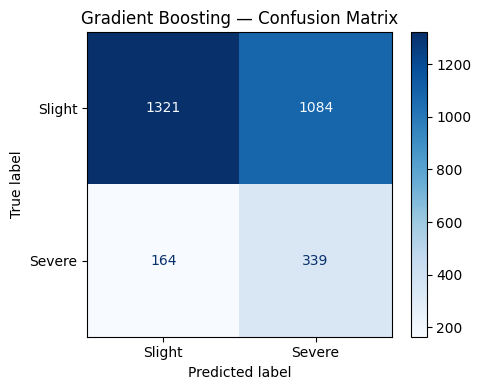

In [27]:
# 5.8 Gradient Boosting: confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gb,
    display_labels=['Slight', 'Severe'],
    cmap='Blues', ax=ax
)
ax.set_title('Gradient Boosting — Confusion Matrix')
plt.tight_layout()
plt.show()

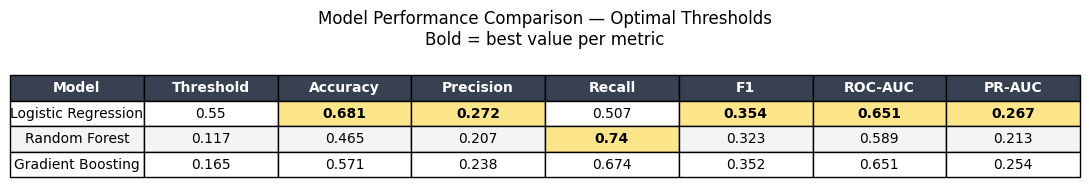

=== Model Comparison ===
              Model  Threshold  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC
Logistic Regression      0.550     0.681      0.272   0.507 0.354    0.651   0.267
      Random Forest      0.117     0.465      0.207   0.740 0.323    0.589   0.213
  Gradient Boosting      0.165     0.571      0.238   0.674 0.352    0.651   0.254


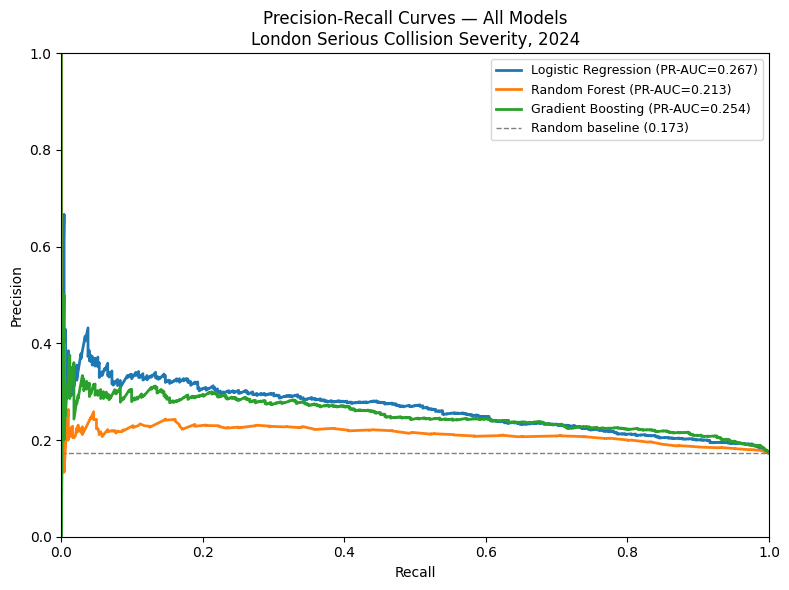

In [28]:
# 5.9 Full model comparison table and PR curves

comparison = pd.DataFrame([lr_metrics, rf_metrics, gb_metrics])
cols = ['Model', 'Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

fig, ax = plt.subplots(figsize=(11, 2))
ax.axis('off')

table = ax.table(
    cellText=comparison[cols].values.tolist(),
    colLabels=cols,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Header: dark grey
for j in range(len(cols)):
    table[0, j].set_facecolor('#374151')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Rows: alternating white and light grey
row_bg = ['#ffffff', '#f3f4f6', '#ffffff']
for i in range(1, 4):
    for j in range(len(cols)):
        table[i, j].set_facecolor(row_bg[i-1])

# Highlight best value per metric in soft amber
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
for col_name in metric_cols:
    col_idx = cols.index(col_name)
    values = comparison[col_name].values
    best_row = values.argmax() + 1
    table[best_row, col_idx].set_facecolor('#fde68a')
    table[best_row, col_idx].set_text_props(fontweight='bold')

ax.set_title(
    'Model Performance Comparison — Optimal Thresholds\n'
    'Bold = best value per metric',
    fontsize=12, pad=20
)
plt.tight_layout()
plt.show()

print("=== Model Comparison ===")
print(comparison[cols].to_string(index=False))

# PR curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, '#2B6CB0'),
    ('Random Forest',       y_prob_rf, '#D97706'),
    ('Gradient Boosting',   y_prob_gb, '#276749'),
]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(rec, prec, label=f'{name} (PR-AUC={ap:.3f})', linewidth=2)

ax.axhline(y_test.mean(), color='grey', linestyle='--', linewidth=1,
           label=f'Random baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — All Models\nLondon Serious Collision Severity, 2024')
ax.legend(fontsize=9)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### 5.1 RQ1: Severe Collision Rates across Crossing Facility and Junction Contexts

EDA revealed that severe collision rates vary substantially across pedestrian crossing facility types, though not in the direction commonly assumed. Footbridge or subway locations recorded the highest severe collision rate at 22.7%, followed by Pelican/Puffin/Toucan crossings at 20.7%, both exceeding the no-facility baseline of 19.6%. Zebra crossings recorded the lowest rate among at-grade facilities at 15.2%. These findings suggest that crossing facility type alone does not predict lower collision severity, and that facilities commonly regarded as protective infrastructure may instead mark locations with elevated pedestrian-vehicle conflict.

The heatmap analysis (EDA 3) further demonstrates that severe collision rates vary dramatically across combinations of crossing facility type and junction context, ranging from 0.00 to 0.44. Footbridge or subway locations at T or staggered junctions recorded the highest combined severe rate of 0.44, nearly twice the overall severe rate of 0.17. This context-dependence indicates that crossing facilities cannot be interpreted in isolation, and that junction type is a critical moderating variable — directly addressing RQ1.

### 5.2 RQ2: Machine Learning Severity Prediction and Feature Importance

**Model Performance**

All three models achieved PR-AUC above the random baseline of 0.173, confirming that road-context and environmental variables carry predictive signal for collision severity. Logistic Regression achieved the highest PR-AUC (0.267) and ROC-AUC (0.651), suggesting that much of the predictive signal in this dataset is captured by linear relationships. Gradient Boosting achieved comparable F1 (0.352) and Recall (0.674), while Random Forest produced the highest Recall (0.740) at the cost of substantially lower Precision (0.207). The modest overall performance across all models is consistent with the inherently limited observability of severity determinants in police-recorded collision data, where factors such as impact speed, driver behaviour, and occupant characteristics are not recorded.

**SHAP Feature Importance**

SHAP analysis of the Gradient Boosting model revealed that the two most influential crossing-facility categories were the absence of crossing facilities: the adjusted no-crossing category (code 9, mean absolute SHAP = 0.119) and no facility within 50 metres (code 0, SHAP = 0.092). In contrast, all facility-present categories recorded substantially lower SHAP values, with Pelican/Puffin/Toucan crossings at 0.018 and Footbridge or subway at 0.004.

This finding suggests that crossing facilities do not act as strong risk signals in the model. Instead, the presence of no facility is the dominant crossing-related predictor. This is consistent with the hypothesis that pedestrian crossing facilities are installed at high-exposure locations, and that their presence may partially mitigate severity conditional on a collision occurring, while their absence marks locations where pedestrians are more exposed to unmediated vehicle conflict.

The correlation analysis further supports a cautious interpretation: pedestrian crossing facilities showed a statistically significant but weak negative correlation with severity (r = −0.075, p < 0.001), indicating that locations with facilities are marginally associated with lower severity. However, this marginal linear association is insufficient to characterise facilities as reliably protective, particularly when junction context introduces substantial heterogeneity in severe rates as demonstrated in EDA 3.

In [29]:
# 5.10 SHAP interpretation on Gradient Boosting

X_shap = X_test.sample(n=500, random_state=42)
explainer = shap.TreeExplainer(gb_model)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP computed for {len(X_shap)} samples, shape: {shap_values.shape}")

SHAP computed for 500 samples, shape: (500, 63)


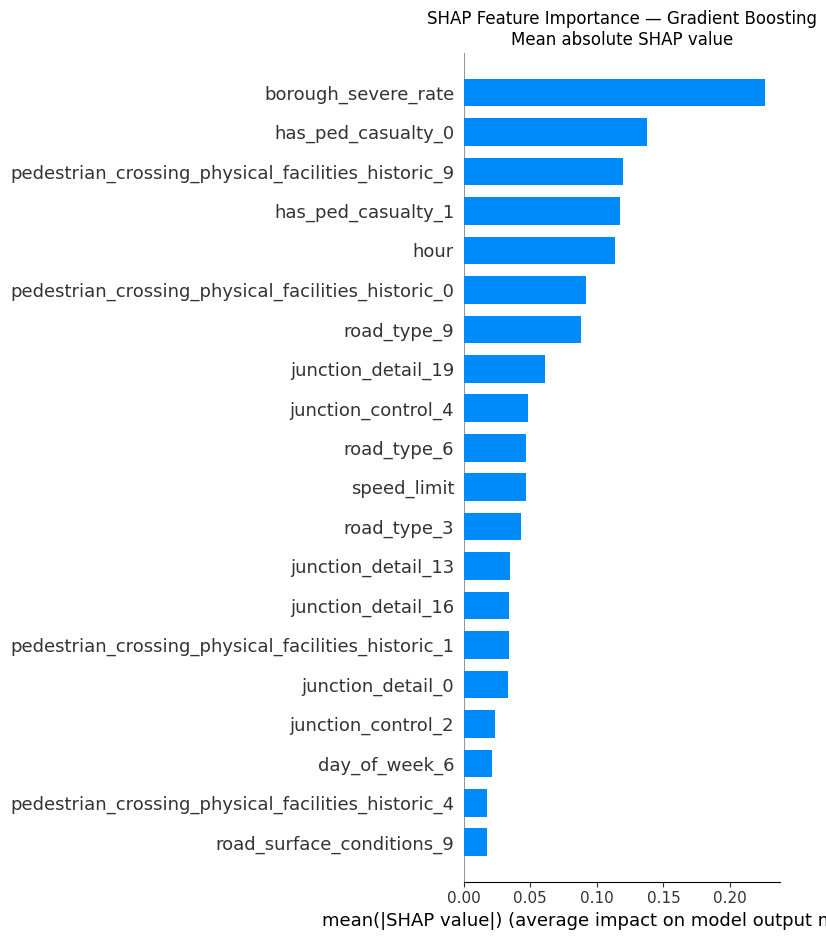

In [30]:
# 5.11 SHAP summary bar chart: global feature importance

shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance — Gradient Boosting\nMean absolute SHAP value')
plt.tight_layout()
plt.show()

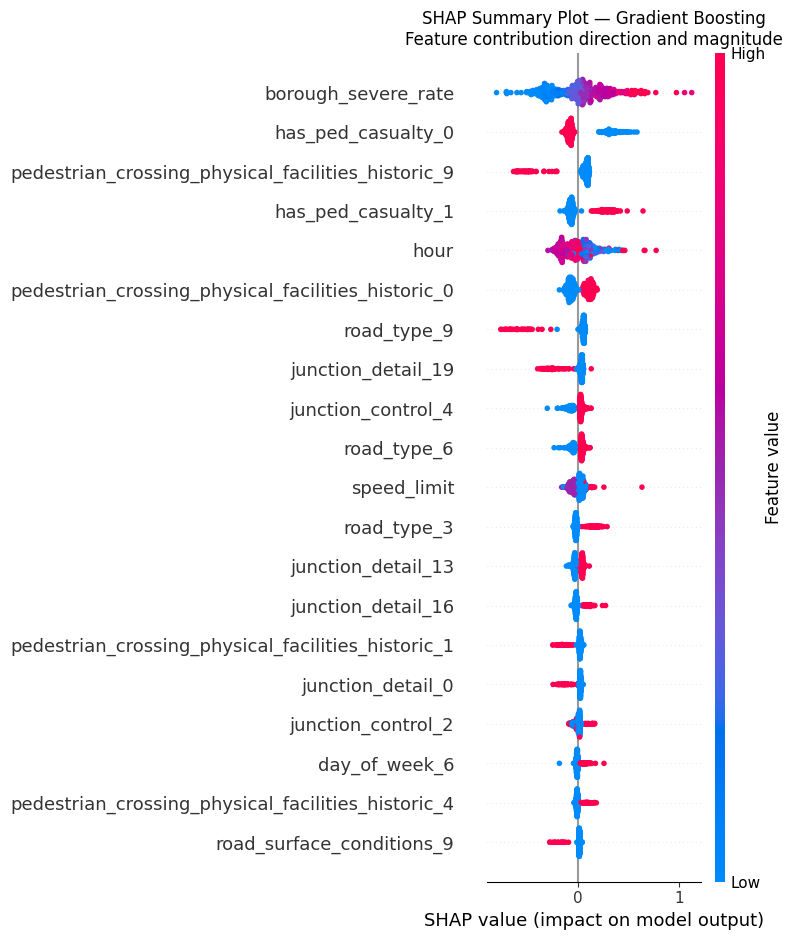

In [31]:
# 5.12 SHAP beeswarm: direction and magnitude of feature effects

shap.summary_plot(shap_values, X_shap, plot_type='dot', max_display=20, show=False)
plt.title('SHAP Summary Plot — Gradient Boosting\nFeature contribution direction and magnitude')
plt.tight_layout()
plt.show()

In [32]:
# 5.13 SHAP values for crossing facility features specifically

crossing_cols = [c for c in X_shap.columns
                 if 'pedestrian_crossing' in c]
crossing_shap = pd.Series(
    np.abs(shap_values[:, [X_shap.columns.get_loc(c) for c in crossing_cols]]).mean(axis=0),
    index=crossing_cols
).sort_values(ascending=False)

print("Mean absolute SHAP values for crossing facility categories:")
print(crossing_shap.to_string())

Mean absolute SHAP values for crossing facility categories:
pedestrian_crossing_physical_facilities_historic_9    0.119384
pedestrian_crossing_physical_facilities_historic_0    0.091874
pedestrian_crossing_physical_facilities_historic_1    0.033569
pedestrian_crossing_physical_facilities_historic_4    0.017578
pedestrian_crossing_physical_facilities_historic_8    0.011643
pedestrian_crossing_physical_facilities_historic_5    0.007994
pedestrian_crossing_physical_facilities_historic_7    0.003654


对照编码表：

_9 = No facility (adjusted) — SHAP最高0.119，最重要

_0 = No facility (within 50m) — SHAP第二0.092

_1 = Zebra crossing — 0.034

_4 = Pelican/Puffin/Toucan — 0.018

_8 = Central refuge — 0.012

_5 = Pedestrian phase at signal junction — 0.008

_7 = Footbridge/Subway — 0.004（最低）

关键发现：两个"无设施"类别（code 0和9）的SHAP重要性远高于所有有设施类别。 这说明模型在预测severity时，最依赖的crossing信号是"没有设施"，而不是"有什么设施"。
这和你的RQ直接相关：crossing facilities本身不是high-risk signal，反而是absence of facilities和adjusted no-facility category携带了最多的预测信息。

## Conclusion

[[ go back to the top ]](#Table-of-contents)

## Conclusion

This study examined whether pedestrian crossing facilities in London are associated with lower serious-collision severity or act as signals of high-risk junction contexts in machine learning predictions, using STATS19 collision records for 2024.

EDA demonstrated that severe collision rates vary across crossing facility types but not in a simple protective direction, with footbridge locations and Pelican/Puffin crossings exceeding the no-facility baseline. Junction context introduced substantial additional variation, with severe rates ranging from near-zero to 0.44 across crossing-junction combinations, confirming that facilities cannot be interpreted without reference to their surrounding road environment.

Machine learning models achieved PR-AUC values between 0.213 and 0.267, all exceeding the random baseline, indicating that road-context variables carry modest but consistent predictive signal. SHAP analysis identified the absence of crossing facilities as the dominant crossing-related predictor, rather than any specific facility type. This partially supports the research question: crossing facilities do not strongly act as high-risk context signals in the model; rather, their absence is the more influential severity predictor.

These findings have implications for road safety targeting. Locations without crossing facilities, particularly at complex junction types, may warrant priority attention in infrastructure investment decisions. However, the modest model performance suggests that collision-context variables in STATS19 explain only a limited portion of severity variation, and that unobserved factors such as vehicle speed at impact, driver behaviour, and pedestrian vulnerability remain critical determinants.

**Limitations and Critical Reflection**

Several limitations apply. First, STATS19 records only police-reported personal injury collisions, and slight collisions are more likely to be under-reported than serious or fatal ones. The model therefore learns patterns in recorded severity rather than true underlying severity. Second, the analysis is restricted to 2024 data, which limits sample size and temporal generalisability. Third, the borough-level severe rate used as a spatial proxy captures neighbourhood-level variation but cannot account for local road network structure or pedestrian exposure volume, the absence of which constitutes the primary confounding factor in interpreting crossing facility effects. Fourth, all models produce predictive associations rather than causal evidence; the presence or absence of crossing facilities may reflect local planning decisions, pedestrian volumes, and historical collision patterns that are not fully captured in the feature set.

## References

[[ go back to the top ]](#Table-of-contents)